In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [6]:
def load_clean_csv(f):
    with open(f, encoding="utf-8-sig") as fh:
        header = fh.readline()
    if header.count(";") > header.count(","):
        return None   # skip the semicolon-delimited file

    df = pd.read_csv(f, encoding="utf-8-sig", on_bad_lines="skip", keep_default_na=False)
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
    df["year"] = f.parent.parent.name
    df["event"] = f.parent.name
    return df

frames = [load_clean_csv(f) for f in race_files]
race_laps = pd.concat([d for d in frames if d is not None], ignore_index=True)

print(sum(d is not None for d in frames), "files loaded,", sum(d is None for d in frames), "skipped")

64 files loaded, 1 skipped


In [ ]:
# the class label in the data is "GTDPRO" (no space)
gtdpro = race_laps[race_laps["CLASS"].str.strip().eq("GTDPRO")].copy()

def to_seconds(t):
    try:
        secs = 0.0
        for part in str(t).strip().split(":"):
            secs = secs * 60 + float(part)
        return secs
    except Exception:
        return None

gtdpro["lap_time_float"] = gtdpro["LAP_TIME"].apply(to_seconds)
gtdpro["LAP_NUMBER"] = pd.to_numeric(gtdpro["LAP_NUMBER"], errors="coerce")

# drop laps with no usable time or lap number
gtdpro = gtdpro.dropna(subset=["lap_time_float", "LAP_NUMBER"])

# put each car's laps in order within each race
gtdpro = gtdpro.sort_values(["year", "event", "NUMBER", "LAP_NUMBER"]).reset_index(drop=True)

print(gtdpro.shape)
print(gtdpro["lap_time_float"].describe())

(99262, 29)
count    99262.000000
mean       115.184385
std         89.849947
min         51.725000
25%         85.753250
50%        108.430000
75%        122.732000
max      10041.714000
Name: lap_time_float, dtype: float64


In [8]:
# Getting rid of laps that create noise
gtdpro["is_fcy"] = gtdpro["FLAG_AT_FL"].str.strip().eq("FCY")
gtdpro["is_green"] = gtdpro["FLAG_AT_FL"].str.strip().eq("GF")
gtdpro["is_pit"] = gtdpro["CROSSING_FINISH_LINE_IN_PIT"].str.strip().eq("B")

car = ["year", "event", "NUMBER"]
g = gtdpro.groupby(car)

gtdpro["out_lap"] = g["is_pit"].shift(1, fill_value=False)
gtdpro["fcy_prev"] = g["is_fcy"].shift(1, fill_value=False)
gtdpro["fcy_next"] = g["is_fcy"].shift(-1, fill_value=False)

print(gtdpro[["is_green", "is_fcy", "is_pit", "out_lap", "fcy_prev", "fcy_next"]].sum())
print(len(gtdpro), "laps remaining after filtering")

is_green    83563
is_fcy      15307
is_pit       3512
out_lap      3502
fcy_prev    15301
fcy_next    15211
dtype: int64
99262 laps remaining after filtering


In [15]:
gtdpro["stint"] = gtdpro.groupby(car)["out_lap"].cumsum()
gtdpro["tire_age"] = gtdpro.groupby(car + ["stint"]).cumcount()

clean = gtdpro[
    gtdpro["is_green"]
    & ~gtdpro["is_pit"]
    & ~gtdpro["out_lap"]
    & ~gtdpro["fcy_prev"]
    & ~gtdpro["fcy_next"]
    & (gtdpro["tire_age"]>= 1)
].copy()

print(gtdpro.shape, clean.shape)
print(clean["lap_time_float"].describe())
print(clean["tire_age"].describe())

(99262, 37) (75147, 37)
count    75147.000000
mean       100.852439
std         34.761826
min         51.725000
25%         83.172500
50%        107.776000
75%        109.327000
max       5050.147000
Name: lap_time_float, dtype: float64
count    75147.000000
mean        16.162468
std         10.396719
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         74.000000
Name: tire_age, dtype: float64


In [19]:
ev = ["year", "event"]
clean["event_median"] = clean.groupby(ev)["lap_time_float"].transform("median")
clean["ratio"] = clean["lap_time_float"] / clean["event_median"]

print(clean["ratio"].describe())

model_df = clean[clean["ratio"].between(.93, 1.07)].copy()
print(clean.shape, model_df.shape)

car = ["year", "event", "NUMBER"]

# only keep cars with enough laps for a reliable median
lap_counts = model_df.groupby(car)["lap_time_float"].transform("count")
model_df = model_df[lap_counts >= 20].copy()

model_df["car_median"] = model_df.groupby(car)["lap_time_float"].transform("median")
model_df["ratio_car"] = model_df["lap_time_float"] / model_df["car_median"]

print(model_df.shape)
print(model_df["ratio_car"].describe(percentiles=[.01, .05, .5, .95, .99]))

count    75147.000000
mean         1.004758
std          0.315238
min          0.970034
25%          0.995218
50%          1.000000
75%          1.005965
max         60.307668
Name: ratio, dtype: float64
(75147, 39) (74522, 39)
(74503, 41)
count    74503.000000
mean         1.001435
std          0.008997
min          0.968178
1%           0.986050
5%           0.990242
50%          1.000000
95%          1.017387
99%          1.034951
max          1.076805
Name: ratio_car, dtype: float64


In [20]:
# one label per stint so we can split by stint
stint_key = ["year", "event", "NUMBER", "stint"]
model_df["stint_id"] = model_df[stint_key].astype(str).agg("|".join, axis=1)

num = ["tire_age", "LAP_NUMBER"]
cat = ["MANUFACTURER", "event"]
X = model_df[num + cat]
y = model_df["ratio"]

# 80% train / 20% test, split by stint
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=model_df["stint_id"]))

# scale the numbers, one-hot encode the categories
pre = ColumnTransformer([
    ("num", StandardScaler(), num),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat),
])

linear = Pipeline([("pre", pre), ("model", LinearRegression())])
boosting = Pipeline([("pre", pre), ("model", HistGradientBoostingRegressor(
    max_depth=4, learning_rate=0.05, max_iter=300, random_state=42))])

# baseline: predict the training average for every test lap
baseline_mae = mean_absolute_error(y.iloc[test_idx], [y.iloc[train_idx].mean()] * len(test_idx))
print("baseline MAE %:", round(baseline_mae * 100, 3))

for name, model in [("linear", linear), ("boosting", boosting)]:
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    pred = model.predict(X.iloc[test_idx])
    print(name, "MAE %:", round(mean_absolute_error(y.iloc[test_idx], pred) * 100, 3),
          "R2:", round(r2_score(y.iloc[test_idx], pred), 4))

# degradation per lap from the linear model (% of lap time)
slope = linear.named_steps["model"].coef_[0] / model_df["tire_age"].std()
print("linear degradation per lap (% of lap time):", round(slope * 100, 4))

baseline MAE %: 0.712
linear MAE %: 0.696 R2: 0.0317
boosting MAE %: 0.672 R2: 0.0883
linear degradation per lap (% of lap time): 0.0101


    linear  boosting
1    0.000     0.000
6    0.051    -0.576
11   0.101    -0.474
16   0.152    -0.371
21   0.202    -0.322
26   0.253    -0.302
31   0.303    -0.305
36   0.354    -0.277
41   0.404    -0.207


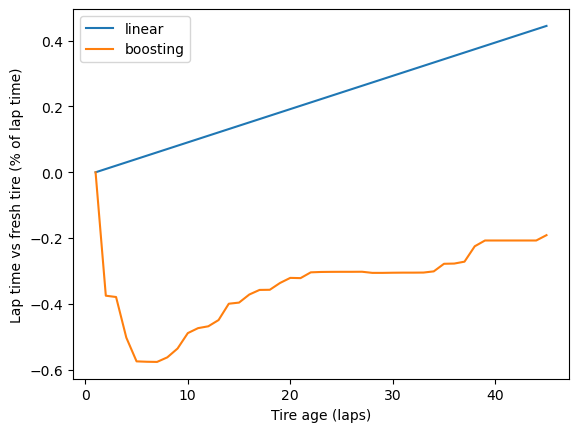

In [21]:
ages = list(range(1, 46))   # cut off at 45 laps, where there's still enough data

curves = {}
for name, model in [("linear", linear), ("boosting", boosting)]:
    avg_pred = []
    for a in ages:
        X_tmp = X.iloc[test_idx].copy()
        X_tmp["tire_age"] = a                      # pretend every lap is on this tire age
        avg_pred.append(model.predict(X_tmp).mean())
    # show change vs a fresh tire, in % of lap time
    curves[name] = (pd.Series(avg_pred, index=ages) - avg_pred[0]) * 100

print(pd.DataFrame(curves).iloc[::5].round(3))

for name, c in curves.items():
    plt.plot(c.index, c.values, label=name)
plt.xlabel("Tire age (laps)")
plt.ylabel("Lap time vs fresh tire (% of lap time)")
plt.legend()
plt.show()